# Analyse + pretraitement + visualisation + grille de points DATASET CLIMAT

In [ ]:
import os
import requests
import zipfile
import re
import rasterio
import numpy as np
import glob
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from rasterio.mask import mask
from shapely.ops import unary_union
from scipy import stats
from scipy.stats import skew, kurtosis
from shapely.geometry import Point
from scipy.stats import mode
from rasterstats import point_query
from concurrent.futures import ThreadPoolExecutor
from plot_functions import plot_boxplots, plot_distributions


In [2]:
 
def download_naturalearth(output_folder="data"):

    """Download Natural Earth shapefile if not present"""
    os.makedirs(output_folder, exist_ok=True)
    shapefile_path = os.path.join(output_folder, "ne_110m_admin_0_countries.shp")

    if not os.path.exists(shapefile_path):
        print("Downloading Natural Earth shapefile...")

        url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
        
        zip_path = os.path.join(output_folder, "ne_countries.zip")

        r = requests.get(url)
        with open(zip_path, "wb") as f:
            f.write(r.content)

        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(output_folder)
        os.remove(zip_path)
        print(" Natural Earth shapefile downloaded and extracted.")
    else:
        print(" Natural Earth shapefile already available.")
    return shapefile_path

In [8]:
 
def get_country_shapes(shapefile_path):
    
    """Extract Algeria and Tunisia polygons"""

    world = gpd.read_file(shapefile_path)

     
    world["COUNTRY"] = world["COUNTRY"].str.strip().str.lower()
    algeria = world[world["COUNTRY"].isin(["algeria", "tunisia"])]

    

    if algeria.empty:
        print(" Could not find Algeria or Tunisia. Available names include:")
        print(world["COUNTRY"].unique())
        raise ValueError("Country names not found in shapefile.")

    print(" Found Algeria and Tunisia in shapefile.")
    return algeria



In [9]:
 
def clip_raster_to_country(raster_path, country_gdf):
    
    """Return clipped raster for a given country"""
    with rasterio.open(raster_path) as src:
        country_geom = [country_gdf.geometry.union_all()]
        clipped_image, clipped_transform = mask(src, country_geom, crop=True)
        clipped_meta = src.meta.copy()
        clipped_meta.update({
            "height": clipped_image.shape[1],
            "width": clipped_image.shape[2],
            "transform": clipped_transform
        })
    return clipped_image[0], clipped_meta


In [16]:

def plot_raster(data, title, cmap="plasma", cbar_label="Value"):
    
    plt.figure(figsize=(9, 7))

    img = plt.imshow(
        data,
        cmap=cmap,
        interpolation="bilinear",   # smoother climatic gradients
        aspect="auto"
    )

    plt.title(title, fontsize=15, fontweight="bold", pad=10)
    plt.xlabel("Longitude (approx.)", fontsize=11)
    plt.ylabel("Latitude (approx.)", fontsize=11)

    cbar = plt.colorbar(
        img,
        fraction=0.035,
        pad=0.04
    )
    cbar.ax.tick_params(labelsize=10)

    plt.tight_layout()
    plt.show()


In [26]:
base_dir = os.path.join(os.getcwd(), "Old_dataset/Climat/5min")
shapefile_path = download_naturalearth()

datasets = {
    "Precipitation": os.path.join(base_dir, "prec"),
    "Tmax": os.path.join(base_dir, "max"),
    "Tmin": os.path.join(base_dir, "min")
    }

 Natural Earth shapefile already available.


# Visualisation des donnees

 Found Algeria and Tunisia in shapefile.

 Processing Precipitation dataset...


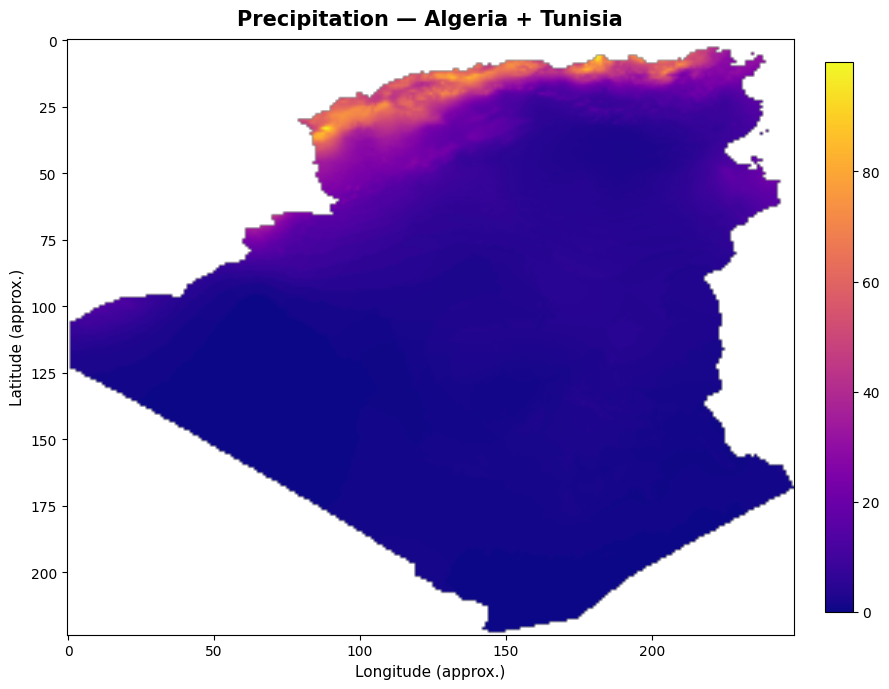


 Processing Tmax dataset...


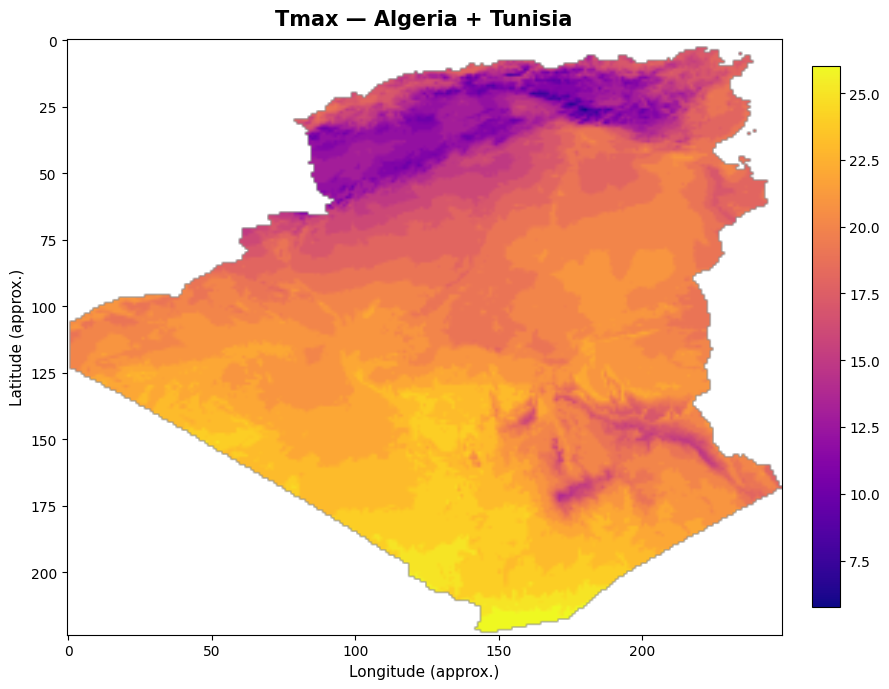


 Processing Tmin dataset...


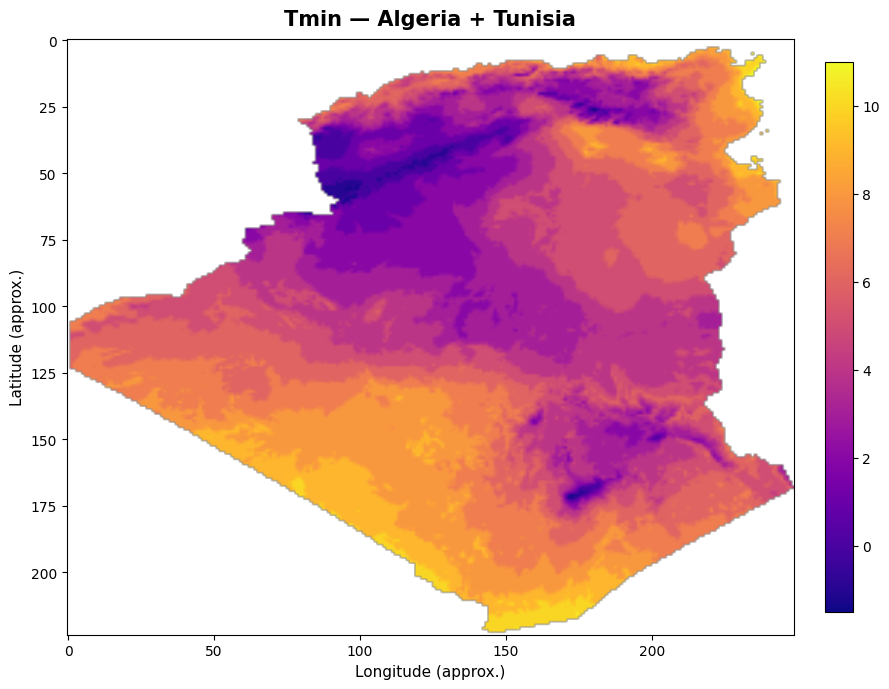

In [ ]:
 
def main():
    
    base_dir = os.path.join(os.getcwd(), "Old_dataset/Climat")


    datasets = {
        "Precipitation": os.path.join(base_dir, "prec"),
        "Tmax": os.path.join(base_dir, "max"),
        "Tmin": os.path.join(base_dir, "min")
    }

    # Download shapefile
    shapefile_path = r"C:\\Users\melom\OneDrive\Desktop\Data mining\shp\alg_tun.shp"
    algeria = get_country_shapes(shapefile_path)

    # Process each dataset
    for name, folder in datasets.items():
        print(f"\n Processing {name} dataset...")
        if not os.path.exists(folder):
            print(f" Folder not found: {folder}")
            continue

        tif_files = sorted([
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.endswith(".tif")
        ])

        if not tif_files:
            print(f" No .tif files found in {folder}")
            continue

        # Use one sample TIF (the first)
        
        sample_tif = tif_files[0]
 
        algeria_clip, _ = clip_raster_to_country(sample_tif, algeria)
        plot_raster(algeria_clip, f"{name} — Algeria + Tunisia")

if __name__ == "__main__":
    main()

# Analyse du dataset

In [29]:
import os
import numpy as np
import pandas as pd
from scipy.stats import mode

def analyse_dataset(name, folder_path, shapefile_path):
    """
    Analyse all clipped rasters for one dataset (Precip, Tmax, Tmin)
    Returns Pandas DataFrames for further visualization.
    """

    print(f"\nProcessing {name} dataset...")

    shapefile_path = r"C:\\Users\melom\OneDrive\Desktop\Data mining\shp\alg_tun.shp"
    country_gdf = get_country_shapes(shapefile_path)

    values = []

    for file in os.listdir(folder_path):
        if file.endswith(".tif"):
            path = os.path.join(folder_path, file)
            try:
                clipped_img, _ = clip_raster_to_country(path, country_gdf)
                img = clipped_img.astype(float)
                values.extend(img.flatten())
            except Exception as e:
                print(f"Error with {file}: {e}")

    if not values:
        print(f"No data found for {name}.")
        return None

    values = np.array(values)

    # -------------------------------
    # DataFrames construction
    # -------------------------------

    df_all = pd.DataFrame({
        "value": values
    })

    df_valid = df_all[np.isfinite(df_all["value"])].copy()

    # -------------------------------
    # Missing values
    # -------------------------------
    missing_values = len(df_all) - len(df_valid)

    print(f"\n{name} — Data summary:")
    print(f"   • Total values: {len(df_all)}")
    print(f"   • Missing / invalid values: {missing_values} ({(missing_values/len(df_all))*100:.2f}%)")

    if df_valid.empty:
        print("   • No valid numerical values found (all NaN or Inf).")
        return None

    # -------------------------------
    # Outlier detection (IQR)
    # -------------------------------
    Q1 = df_valid["value"].quantile(0.25)
    Q3 = df_valid["value"].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_outliers = df_valid[
        (df_valid["value"] < lower_bound) |
        (df_valid["value"] > upper_bound)
    ].copy()

    print(f"   • Outliers detected: {len(df_outliers)} ({(len(df_outliers)/len(df_valid))*100:.2f}% of valid data)")
    print(f"     Normal range (IQR): [{lower_bound:.2f}, {upper_bound:.2f}]")

    # -------------------------------
    # Statistics
    # -------------------------------
    mean_val = df_valid["value"].mean()
    median_val = df_valid["value"].median()
    mode_result = mode(df_valid["value"], nan_policy="omit")

    mode_val = (
        mode_result.mode.item()
        if np.ndim(mode_result.mode) == 0
        else mode_result.mode[0]
    )


    units = {
        "Precipitation": "mm",
        "Tmax": "°C",
        "Tmin": "°C"
    }.get(name, "unitless")

    stats_df = pd.DataFrame({
        "metric": ["mean", "median", "mode", "Q1", "Q3", "IQR"],
        "value": [mean_val, median_val, mode_val, Q1, Q3, IQR],
        "units": units
    })

    print(f"\n{name} Statistics (valid values only):")
    print(stats_df)

    # -------------------------------
    # Return structured results
    # -------------------------------
    return {
        "name": name,
        "units": units,
        "all_values": df_all,
        "valid_values": df_valid,
        "outliers": df_outliers,
        "stats": stats_df
    }



Processing Precipitation dataset...
 Found Algeria and Tunisia in shapefile.

Precipitation — Data summary:
   • Total values: 4685184
   • Missing / invalid values: 1930740 (41.21%)
   • Outliers detected: 393523 (14.29% of valid data)
     Normal range (IQR): [-4.73, 9.88]

Precipitation Statistics (valid values only):
   metric     value units
0    mean  6.138569    mm
1  median  1.600000    mm
2    mode  0.000000    mm
3      Q1  0.750000    mm
4      Q3  4.400000    mm
5     IQR  3.650000    mm


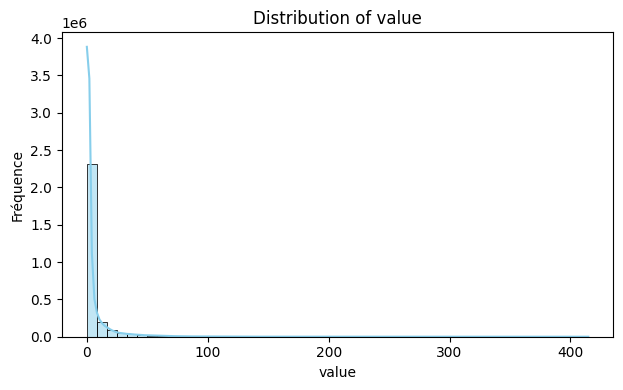

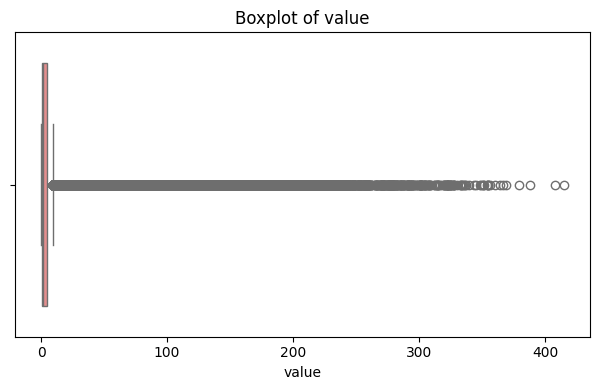


Processing Tmax dataset...
 Found Algeria and Tunisia in shapefile.

Tmax — Data summary:
   • Total values: 4685184
   • Missing / invalid values: 1930740 (41.21%)
   • Outliers detected: 0 (0.00% of valid data)
     Normal range (IQR): [2.25, 60.25]

Tmax Statistics (valid values only):
   metric      value units
0    mean  30.982574    °C
1  median  31.000000    °C
2    mode  40.000000    °C
3      Q1  24.000000    °C
4      Q3  38.500000    °C
5     IQR  14.500000    °C


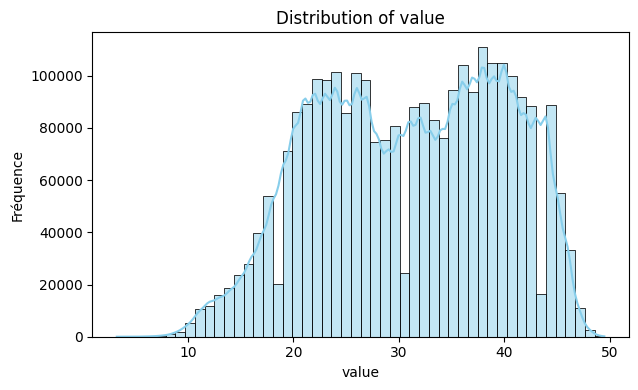

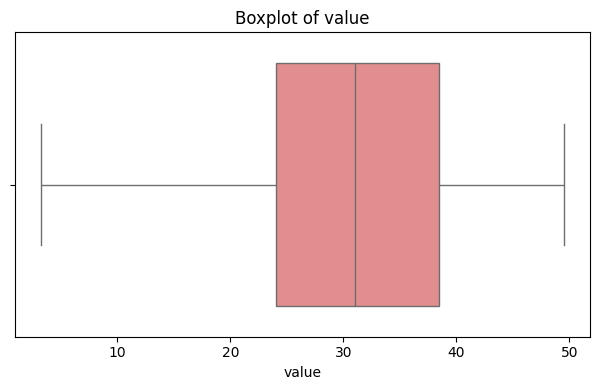


Processing Tmin dataset...
 Found Algeria and Tunisia in shapefile.

Tmin — Data summary:
   • Total values: 4685184
   • Missing / invalid values: 1930740 (41.21%)
   • Outliers detected: 0 (0.00% of valid data)
     Normal range (IQR): [-13.50, 46.50]

Tmin Statistics (valid values only):
   metric      value units
0    mean  16.464283    °C
1  median  16.500000    °C
2    mode  24.000000    °C
3      Q1   9.000000    °C
4      Q3  24.000000    °C
5     IQR  15.000000    °C


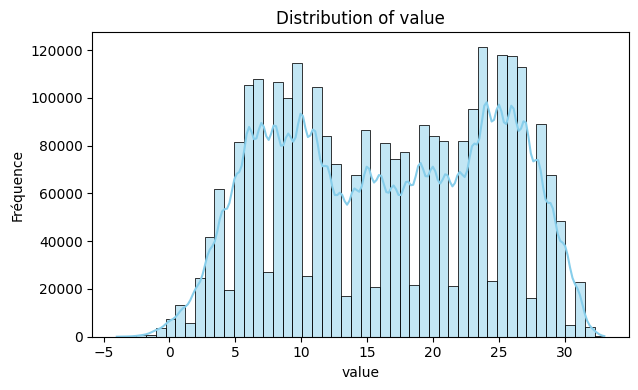

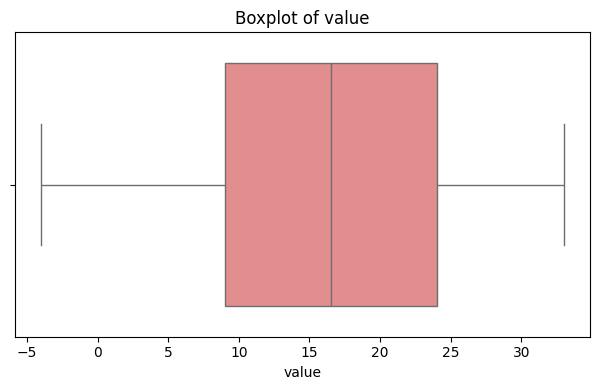

In [30]:
for name, path in datasets.items():


    result_precip = analyse_dataset(
    name=name,
    folder_path = path,
    shapefile_path=shapefile_path
    )

    df_valid = result_precip["valid_values"]

    # Your own plotting functions
    plot_distributions(df_valid, title_prefix="Distribution of")
    plot_boxplots(df_valid, title_prefix="Boxplot of")


# Extraction of the longitude and latitude values

In [31]:
import geopandas as gpd
import rasterio
import pandas as pd
import glob
import os
from tqdm import tqdm
import numpy as np

def extract_features_yearly_monthly_clim(
    point_csv: str,
    fire_csv: str,
    raster_dict: dict,  # keys: "YYYY-MM"
    lat_col="latitude",
    lon_col="longitude",
    fire_year_col="year",
    output_path=None,
    col_name="clim",
    agg_mode="median",
):

    # --- Load datasets ---
    df_points = pd.read_csv(point_csv)
    df_fire = pd.read_csv(fire_csv)

    # Must have same length & matching rows
    assert len(df_points) == len(
        df_fire
    ), "point_csv and fire_csv must align row-by-row"

    # Attach the fire year to points
    df_points["year"] = df_fire[fire_year_col].astype(int)

    # Prepare columns for 12 months
    for mm in range(1, 13):
        df_points[f"m{mm:02d}"] = np.nan

    # --- SAMPLE MONTH-BY-MONTH BUT YEAR PER POINT ---
    for mm in range(1, 13):
        month_str = f"{mm:02d}"

        print(f"\n📅 Processing month {month_str} ...")

        # For each YEAR appearing in data
        for year in df_points["year"].unique():
            key = f"{year}-{month_str}"

            if key not in raster_dict:
                print(f"⚠️ Missing raster for {key}, skipping.")
                continue

            raster_path = raster_dict[key]
            subset_idx = df_points[df_points["year"] == year].index
            subset = df_points.loc[subset_idx]

            coords = list(zip(subset[lon_col], subset[lat_col]))

            with rasterio.open(raster_path) as src:
                nodata = src.nodata
                sampled_vals = [
                    v[0] if v[0] is not None and v[0] != nodata else np.nan
                    for v in src.sample(coords)
                ]

            df_points.loc[subset_idx, f"m{month_str}"] = sampled_vals

    print("\n✅ Finished sampling all monthly rasters per YEAR.")

    # --- Define seasons ---
    winter_cols = ["m12", "m01", "m02"]
    spring_cols = ["m03", "m04", "m05"]
    summer_cols = ["m06", "m07", "m08"]
    autumn_cols = ["m09", "m10", "m11"]

    agg_func = "median" if agg_mode == "median" else "mean"

    # --- Seasonal aggregation ---
    df_points[f"winter_{col_name}"] = df_points[winter_cols].agg(agg_func, axis=1)
    df_points[f"spring_{col_name}"] = df_points[spring_cols].agg(agg_func, axis=1)
    df_points[f"summer_{col_name}"] = df_points[summer_cols].agg(agg_func, axis=1)
    df_points[f"autumn_{col_name}"] = df_points[autumn_cols].agg(agg_func, axis=1)

    # Output columns
    final_cols = [
        lat_col,
        lon_col,
        "year",
        f"winter_{col_name}",
        f"spring_{col_name}",
        f"summer_{col_name}",
        f"autumn_{col_name}",
    ]
    final_df = df_points[final_cols]

    if output_path:
        final_df.to_csv(output_path, index=False)
        print(f"\n💾 Saved seasonal climatology to {output_path}")

    return final_df


def organize_climat_files(data_folder_path):
    tmax_paths = glob.glob(data_folder_path)
    # Change the dictionary to store files keyed by 'YYYY-MM'
    monthly_files = {}

    for file_path in tmax_paths:
        filename = os.path.basename(file_path)

        try:
            # 1. Strip the file extension (.tif)
            base_name = filename.rsplit(".", 1)[0]
            parts = base_name.split("_")
            date_part = parts[-1]  # This should be '2020-02'

            # 3. Split the date_part (YYYY-MM) into year and month
            year, month = date_part.split("-")

            # The new key will be a combination of year and month (e.g., '2020-02')
            file_key = f"{year}-{month}"

            # Basic validation check:
            # Check if year is 4 digits and month is 2 digits and they are numeric
            if (
                len(year) == 4
                and year.isdigit()
                and len(month) == 2
                and month.isdigit()
            ):
                # Store the file path using the 'YYYY-MM' key
                monthly_files[file_key] = file_path

        except (IndexError, ValueError):
            continue

    return monthly_files


# Organize the files
tmax_data = organize_climat_files(
    r"C:\Users\melom\OneDrive\Desktop\Data mining\Old_dataset\Climat\5min\max\*.tif"
)
tmin_data = organize_climat_files(
    r"C:\Users\melom\OneDrive\Desktop\Data mining\Old_dataset\Climat\5min\min\*.tif"
)
prec_data = organize_climat_files(
    r"C:\Users\melom\OneDrive\Desktop\Data mining\Old_dataset\Climat\5min\prec\*.tif"
)
print(tmax_data)

{'2018-01': 'C:\\Users\\melom\\OneDrive\\Desktop\\Data mining\\Old_dataset\\Climat\\5min\\max\\wc2.1_cruts4.09_5m_tmax_2018-01.tif', '2018-02': 'C:\\Users\\melom\\OneDrive\\Desktop\\Data mining\\Old_dataset\\Climat\\5min\\max\\wc2.1_cruts4.09_5m_tmax_2018-02.tif', '2018-03': 'C:\\Users\\melom\\OneDrive\\Desktop\\Data mining\\Old_dataset\\Climat\\5min\\max\\wc2.1_cruts4.09_5m_tmax_2018-03.tif', '2018-04': 'C:\\Users\\melom\\OneDrive\\Desktop\\Data mining\\Old_dataset\\Climat\\5min\\max\\wc2.1_cruts4.09_5m_tmax_2018-04.tif', '2018-05': 'C:\\Users\\melom\\OneDrive\\Desktop\\Data mining\\Old_dataset\\Climat\\5min\\max\\wc2.1_cruts4.09_5m_tmax_2018-05.tif', '2018-06': 'C:\\Users\\melom\\OneDrive\\Desktop\\Data mining\\Old_dataset\\Climat\\5min\\max\\wc2.1_cruts4.09_5m_tmax_2018-06.tif', '2018-07': 'C:\\Users\\melom\\OneDrive\\Desktop\\Data mining\\Old_dataset\\Climat\\5min\\max\\wc2.1_cruts4.09_5m_tmax_2018-07.tif', '2018-08': 'C:\\Users\\melom\\OneDrive\\Desktop\\Data mining\\Old_dataset\\

In [32]:
extract_features_yearly_monthly_clim(
    point_csv="Cleaned_dataset/grid/algeria_tunisia_grid.csv",
    fire_csv = "Cleaned_dataset/grid/fire_grid.csv",
    raster_dict=tmax_data,
    output_path="Cleaned_dataset/grid/grid_tmax.csv",
    col_name="tmax",
)


extract_features_yearly_monthly_clim(
    point_csv="Cleaned_dataset/grid/algeria_tunisia_grid.csv",
    fire_csv = "Cleaned_dataset/grid/fire_grid.csv",
    raster_dict=tmin_data,
    output_path="Cleaned_dataset/grid/grid_tmin.csv",
    col_name="tmin",
)


extract_features_yearly_monthly_clim(
    point_csv="Cleaned_dataset/grid/algeria_tunisia_grid.csv",
    fire_csv = "Cleaned_dataset/grid/fire_grid.csv",
    raster_dict=prec_data,
    output_path="Cleaned_dataset/grid/grid_tprec.csv",
    col_name="prec",
)


📅 Processing month 01 ...

📅 Processing month 02 ...

📅 Processing month 03 ...

📅 Processing month 04 ...

📅 Processing month 05 ...

📅 Processing month 06 ...

📅 Processing month 07 ...

📅 Processing month 08 ...

📅 Processing month 09 ...

📅 Processing month 10 ...

📅 Processing month 11 ...

📅 Processing month 12 ...

✅ Finished sampling all monthly rasters per YEAR.

💾 Saved seasonal climatology to Cleaned_dataset/grid/grid_tmax.csv

📅 Processing month 01 ...

📅 Processing month 02 ...

📅 Processing month 03 ...

📅 Processing month 04 ...

📅 Processing month 05 ...

📅 Processing month 06 ...

📅 Processing month 07 ...

📅 Processing month 08 ...

📅 Processing month 09 ...

📅 Processing month 10 ...

📅 Processing month 11 ...

📅 Processing month 12 ...

✅ Finished sampling all monthly rasters per YEAR.

💾 Saved seasonal climatology to Cleaned_dataset/grid/grid_tmin.csv

📅 Processing month 01 ...

📅 Processing month 02 ...

📅 Processing month 03 ...

📅 Processing month 04 ...

📅 Pro

,latitude,longitude,year,winter_prec,spring_prec,summer_prec,autumn_prec
0,34.000231,-1.653868,2018,36.250000,61.550003,7.525,45.674999
1,34.000231,-1.633868,2024,21.650002,13.600000,10.100,16.500000
2,34.000231,-1.613868,2023,27.275000,25.600000,0.875,12.250000
3,34.000231,-1.593868,2024,21.650002,13.600000,10.100,16.500000
4,34.000231,-1.573868,2024,22.299999,13.650000,10.425,16.725000
...,...,...,...,...,...,...,...
82689,37.320231,9.806132,2024,86.550003,23.325001,4.050,39.799999
82690,37.320231,9.826132,2021,55.075001,46.875000,5.150,80.724998
82691,37.320231,9.846132,2021,NaN,NaN,NaN,NaN
82692,37.320231,9.866132,2024,NaN,NaN,NaN,NaN
